# Analysis of Inverse Modeling Results for Soil Volumetric Liquid Water Content (VWC)

This script analyzes the results of the inverse modeling experiment, focusing on the performance of different parameter sets in reproducing observed soil VWC at two depths (75mm and 1850mm). The analysis includes loading performance metrics (R² and RMSE), identifying top-performing runs, and visualizing simulated vs. observed VWC for selected runs.

This will inform the ranges of parameter values that we use in our ensemble simulation.

## Methodology

1. **Load Data:**
   - Loads performance metrics (R² and RMSE) calculated for each ensemble member at each depth and lysimeter (L1 and L2).
   - Loads the parameter grid defining the parameter combinations used in the ensemble.
   - Loads simulated VWC data for both depths.
   - Loads observed VWC data for both lysimeters at both depths.
   - Filters and aggregates observed data to the relevant time period and hourly intervals.

2. **Identify Top-Performing Runs:**
   - Filters the parameter grid to runs where the near-surface soil saturated water content (wsat_1) is greater than or equal to 0.37.
   - Sorts the performance metrics for each depth and lysimeter combination by R² (descending) and then RMSE (ascending).
   - Prints the top-performing runs based on these criteria.

3. **Plot Results:**
   - For each depth (75mm and 1850mm), creates a time-series plot comparing the observed VWC for a specific lysimeter (L1 or L2) with the simulated VWC from a selected top-performing run.
   (Note: the plots are not publication-ready and are intended for a quick visual check of the model performance.)

## File Paths

* **Input Data:**
    - Performance metrics:
      - L1 75mm: `./Results/InverseModeling_L1_75mm.txt`
      - L2 75mm: `./Results/InverseModeling_L2_75mm.txt`
      - L1 1850mm: `./Results/InverseModeling_L1_1850mm.txt`
      - L2 1850mm: `./Results/InverseModeling_L2_1850mm.txt`
    - Parameter grid: `./Results/param_scenarios_5Params_Mar8.csv`
    - Simulated VWC:
      - 75mm: `./Results/WSOIL75mm_5Params_Mar8.parquet`
      - 1850mm: `./Results/WSOIL1850mm_5Params_Mar8.parquet`
    - Observed VWC: `../Data/FieldSoilMoisture_4Enclosures_4Lysimeters_201806_202210.parquet`

## Dependencies

- **Python libraries:** `pathlib`, `pandas`, `matplotlib.pyplot`, `seaborn`

## Key Outputs

- Printed tables showing the top-performing runs based on R² and RMSE.
- Time-series plots comparing observed and simulated VWC for selected runs at 75mm and 1850mm depths.

## Author

Alireza Amani (alireza.amani101@gmail.com)

## Date

2024-07-23

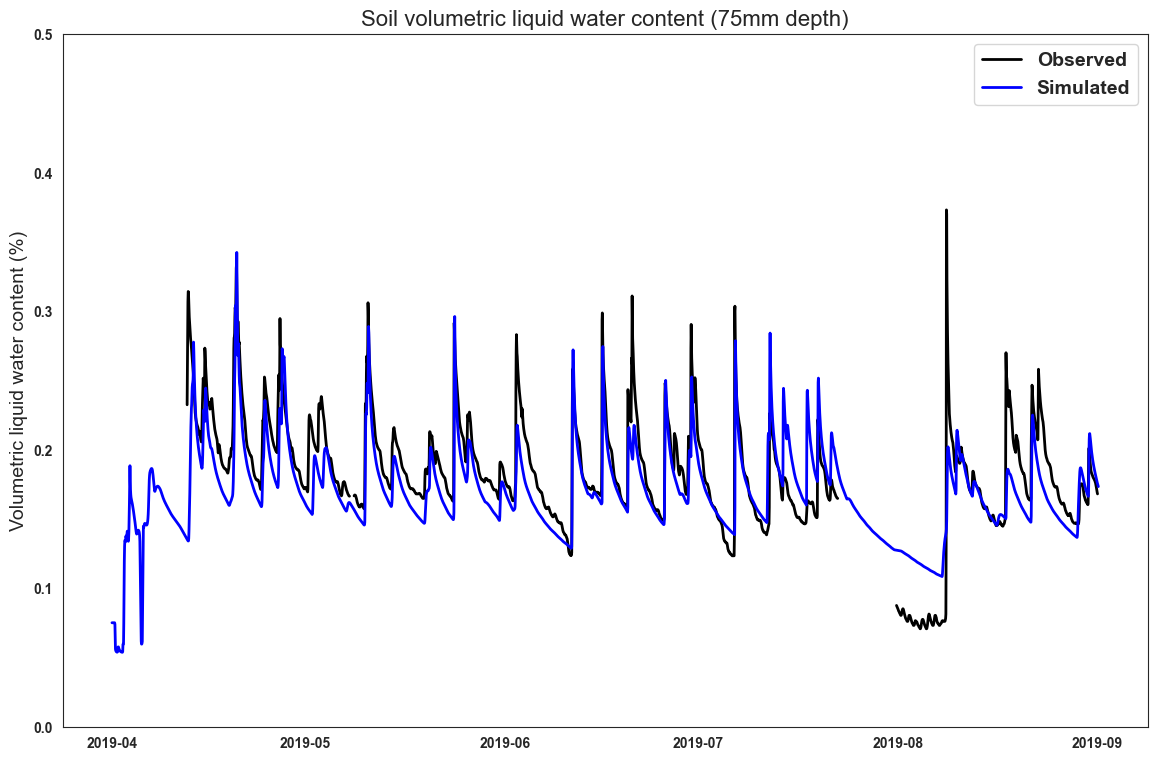

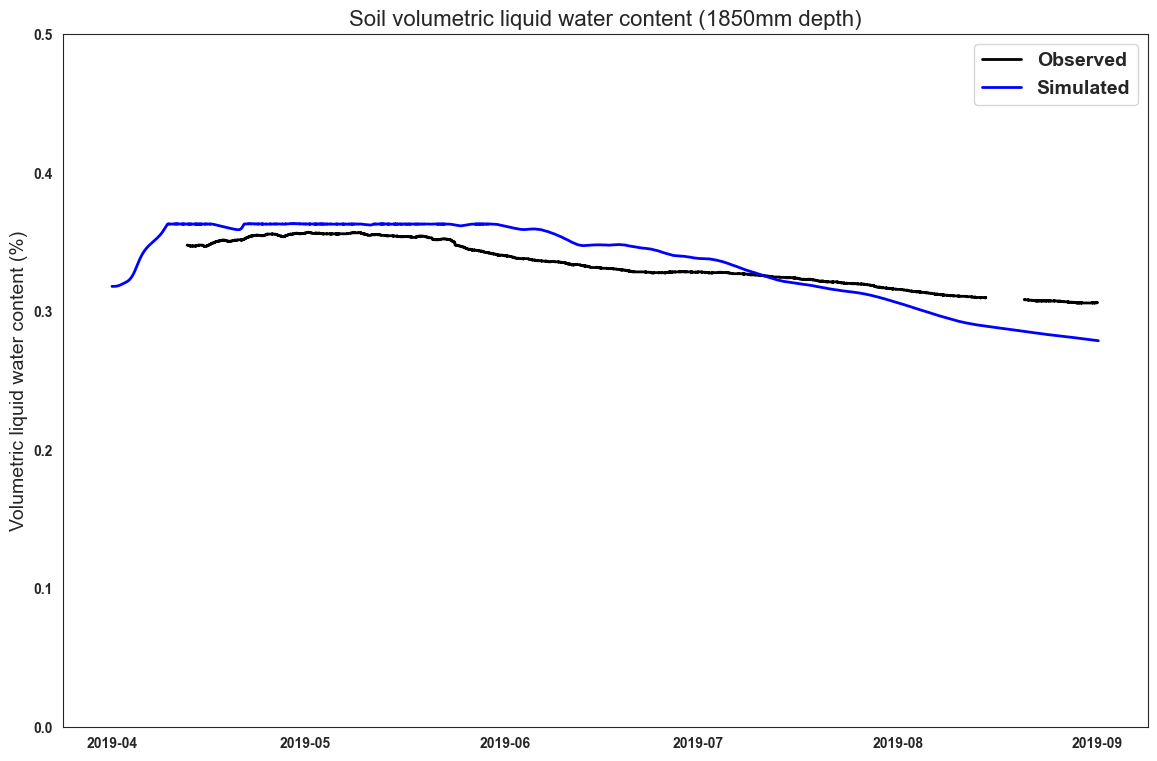

In [43]:
# 1) Importing Libraries -------------------------------------------------------
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ______________________________________________________________________________
# 2) Variables -----------------------------------------------------------------

## paths
paths = dict(
    L1_75mm_wsoil = Path("./Results/InverseModeling_L1_75mm.txt"),
    L2_75mm_wsoil = Path("./Results/InverseModeling_L2_75mm.txt"),
    L1_1850mm_wsoil = Path("./Results/InverseModeling_L1_1850mm.txt"),
    L2_1850mm_wsoil = Path("./Results/InverseModeling_L2_1850mm.txt"),

    param_grid = Path("./Results/param_scenarios_5Params_Mar8.csv"),

    sim_wsoil_75mm = Path("./Results/WSOIL75mm_5Params_Mar8.parquet"),
    sim_wsoil_1850mm = Path("./Results/WSOIL1850mm_5Params_Mar8.parquet"),
    obs_wsoil = Path("../Data/FieldSoilMoisture_4Enclosures_4Lysimeters_201806_202210.parquet"),
)

### assertions
for path in paths.values():
    assert path.exists(), f"Path not found: {path}"

## Column types (member	r2	rmse)
col_types = dict(
    member = str,
    r2 = float,
    rmse = float,
)

## keep cols from param grid
param_cols = [
    "run_id",
    "wsat_1", "wsat_44", "ksat_1", "ksat_44", "bcoef_1", "bcoef_44",
    "psisat_1", "psisat_44", "wfc_1", "wfc_44", "wwilt_1", "wwilt_44",
]

## t0 and t1 for inverse modeling
T0 = pd.Timestamp("2019-04-01 00:00:00+00:00")
T1 = pd.Timestamp("2019-09-01 00:00:00+00:00")

# ______________________________________________________________________________
# 3) Load Data -----------------------------------------------------------------

## load evaluation metrics
metrics_wsoil75mm_l1 = pd.read_csv(paths["L1_75mm_wsoil"], sep=",", dtype=col_types)
metrics_wsoil75mm_l2 = pd.read_csv(paths["L2_75mm_wsoil"], sep=",", dtype=col_types)
metrics_wsoil1850mm_l1 = pd.read_csv(paths["L1_1850mm_wsoil"], sep=",", dtype=col_types)
metrics_wsoil1850mm_l2 = pd.read_csv(paths["L2_1850mm_wsoil"], sep=",", dtype=col_types)

## load param grid
param_grid = pd.read_csv(paths["param_grid"], sep=",", dtype={"run_id": str}, usecols=param_cols)

## load sim data
sim_wsoil_75mm = pd.read_parquet(paths["sim_wsoil_75mm"])
sim_wsoil_1850mm = pd.read_parquet(paths["sim_wsoil_1850mm"])

## load obs data
obs_wsoil = pd.read_parquet(paths["obs_wsoil"])
obs_wsoil.index = pd.to_datetime(obs_wsoil["Date Time (UTC)"])

### 75 mm L1 and L2
obs_wsoil_75mm_L1 = obs_wsoil.query("Unique_label_ == 'L1_75mm_ext_Moisture_percent'").copy()
obs_wsoil_75mm_L2 = obs_wsoil.query("Unique_label_ == 'L2_75mm_ext_Moisture_percent'").copy()

### 1850 mm L1 and L2
obs_wsoil_1850mm_L1 = obs_wsoil.query("Unique_label_ == 'L1_1850mm_int_Moisture_percent'").copy()
obs_wsoil_1850mm_L2 = obs_wsoil.query("Unique_label_ == 'L2_1850mm_int_Moisture_percent'").copy()

### only t0 and t1
obs_wsoil_75mm_L1 = obs_wsoil_75mm_L1.loc[T0:T1]
obs_wsoil_75mm_L2 = obs_wsoil_75mm_L2.loc[T0:T1]
obs_wsoil_1850mm_L1 = obs_wsoil_1850mm_L1.loc[T0:T1]
obs_wsoil_1850mm_L2 = obs_wsoil_1850mm_L2.loc[T0:T1]

### agg to hourly
obs_wsoil_75mm_L1 = obs_wsoil_75mm_L1.resample("h").mean(numeric_only=True)
obs_wsoil_75mm_L2 = obs_wsoil_75mm_L2.resample("h").mean(numeric_only=True)
# ______________________________________________________________________________
# 4) Main ----------------------------------------------------------------------

## 75mm grid; keep run_id s where wsat_1 >= 0.37
nearsurface_run_ids = param_grid.query("wsat_1 >= 0.37")["run_id"].tolist()

## filter and sort: find runs with best r2 and lowest rmse (print them in a separate cell)
metrics_wsoil75mm_l1.query("member in @nearsurface_run_ids").sort_values("r2", ascending=False).head(100).sort_values("rmse").head(10)
metrics_wsoil75mm_l2.query("member in @nearsurface_run_ids").sort_values("r2", ascending=False).head(100).sort_values("rmse").head(10)
metrics_wsoil1850mm_l1.sort_values("r2", ascending=False).head(100).sort_values("rmse").head(10)
metrics_wsoil1850mm_l2.sort_values("r2", ascending=False).head(100).sort_values("rmse").head(10)


# ______________________________________________________________________________
# 5) Plotting ------------------------------------------------------------------

## all fonts to Arial and Bold
plt.rcParams["font.family"] = "Arial"
plt.rcParams["font.weight"] = "bold"
sns.set_style("white")

## plot best run (e.g. 0201010101 or 0403020004) vs L1 (L1_75mm_ext_Moisture_percent) for 75mm
fig, ax = plt.subplots(figsize=(14, 9))

## plot obs
ax.plot(
    obs_wsoil_75mm_L1["Reading"],
    label="Observed",
    color="black",
    linestyle="-",
    linewidth=2,
)

## plot sim
ax.plot(
    sim_wsoil_75mm.loc[sim_wsoil_75mm.member == "0403020004", "WSOIL_3_WSOIL_4"],
    label="Simulated",
    color="blue",
    linestyle="-",
    linewidth=2,
)

## plot formatting
ax.set_title("Soil volumetric liquid water content (75mm depth)", fontsize=16)
ax.set_xlabel("", fontsize=14)
ax.set_ylabel("Volumetric liquid water content (%)", fontsize=14)
ax.legend(fontsize=14)
ax.set_ylim(0, 0.5)
plt.show()

## plot best run (e.g. 0200060400) vs L2 (L2_1850mm_int_Moisture_percent) for 1850mm
fig, ax = plt.subplots(figsize=(14, 9))

## plot obs
ax.plot(
    obs_wsoil_1850mm_L2["Reading"],
    label="Observed",
    color="black",
    linestyle="-",
    linewidth=2,
)

## plot sim
ax.plot(
    sim_wsoil_1850mm.loc[sim_wsoil_1850mm.member == "0200060400", "WSOIL_42_WSOIL_43"],
    label="Simulated",
    color="blue",
    linestyle="-",
    linewidth=2,
)

## plot formatting
ax.set_title("Soil volumetric liquid water content (1850mm depth)", fontsize=16)
ax.set_xlabel("", fontsize=14)
ax.set_ylabel("Volumetric liquid water content (%)", fontsize=14)
ax.legend(fontsize=14)
ax.set_ylim(0, 0.5)
plt.show()